# Accumulation loss in PyCBC's CPU chi-square calculation

PyCBC's CPU signal-consistency calculation forms a complex sum $q_b$ in each frequency bin and then adds bin powers:
\[
q_b(t)=\sum_{k\in b}c_k e^{2\pi i kt/N},\qquad
S=\sum_b|q_b|^2,\qquad \chi^2=(pS-|z|^2)A^2.
\]
Here $c_k$ is the correlation spectrum, $N$ its length, $t$ a sample index, $p$ the bin count, $z$ the unnormalized SNR and $A$ its normalization.

This notebook tests whether many small positive additions survive after a larger value. **Set $t=0$: every phase is exactly one**, excluding phase drift, π and index-casting effects. Powers of two make the input coefficients exactly representable. Both comparisons use actual compiled [upstream](kernels/upstream.pyx) and [double-precision](kernels/arithmetic.pyx) kernels, complex64 inputs and float32 outputs.

## Run

Run beside `cpu_chisq_review.py` with PyCBC, NumPy, Matplotlib, Cython and a C++ compiler installed. **Restart Kernel and Run All**; the helper compiles and caches kernels using identical flags.

In [1]:
import warnings
warnings.filterwarnings("ignore", message="Wswiglal-redir-stdio:")

import sys
import numpy as np
import matplotlib.pyplot as plt
from pycbc.scheme import CPUScheme
from pycbc.types import Array
from cpu_chisq_review import kernels, load_capture, plot_style

plot_style()
cpu = kernels(("upstream", "arithmetic"))
variants = ("upstream", "arithmetic")
labels = {"upstream": "Upstream", "arithmetic": "Double working precision"}
colors = {"upstream": "#245885", "arithmetic": "#B77818"}
capture = load_capture()
captured_width = int(np.max(np.diff(capture["bins"])))
captured_bins = len(capture["bins"]) - 1
print(f"Python {sys.version.split()[0]} | NumPy {np.__version__}")
print("CPU source: gwastro/pycbc@454ee900e (2026-09-22 upstream snapshot)")

Python 3.13.7 | NumPy 2.3.5
CPU source: gwastro/pycbc@454ee900e (2026-09-22 upstream snapshot)


## Within one bin

Use $c=[1,2^{-26},\ldots,2^{-26}]$ with $m$ coefficients. The exact power is
$S=[1+(m-1)2^{-26}]^2$.
Each small addition is below half a float32 spacing at 1, so repeated rounding can discard it. There is only one bin: summing powers across bins cannot explain this discrepancy.

In [2]:
within_counts = np.unique(np.r_[2 ** np.arange(1, 20), captured_width])
within_exact = (1 + (within_counts - 1) * 2.**-26)**2
within = {name: [] for name in variants}
with CPUScheme():
    for count in within_counts:
        values = np.full(int(count), 2.**-26, dtype=np.complex64)
        values[0] = 1
        correlation = Array(values, copy=False)
        for name in variants:
            result = cpu[name].shift_sum(correlation, [0], [0, int(count)])
            assert result.dtype == np.dtype(np.float32)
            within[name].append(float(result[0]))
within = {name: np.asarray(values) for name, values in within.items()}
np.testing.assert_allclose(within["arithmetic"], within_exact, rtol=1e-7, atol=0)

## Across bins

Now put each coefficient of $[1,2^{-13},\ldots,2^{-13}]$ in its own bin. For $p$ bins, exact $S=1+(p-1)2^{-26}$. Each bin contains one term: this removes within-bin accumulation and isolates adding small powers to the total.

In [3]:
across_counts = np.unique(np.r_[2 ** np.arange(1, 11), 257, captured_bins])
across_exact = 1 + (across_counts - 1) * 2.**-26
across = {name: [] for name in variants}
with CPUScheme():
    for count in across_counts:
        values = np.full(int(count), 2.**-13, dtype=np.complex64)
        values[0] = 1
        correlation = Array(values, copy=False)
        bins = np.arange(int(count) + 1, dtype=np.uint32)
        for name in variants:
            result = cpu[name].shift_sum(correlation, [0], bins)
            assert result.dtype == np.dtype(np.float32)
            across[name].append(float(result[0]))
across = {name: np.asarray(values) for name, values in across.items()}
np.testing.assert_allclose(across["arithmetic"], across_exact, rtol=1e-7, atol=0)

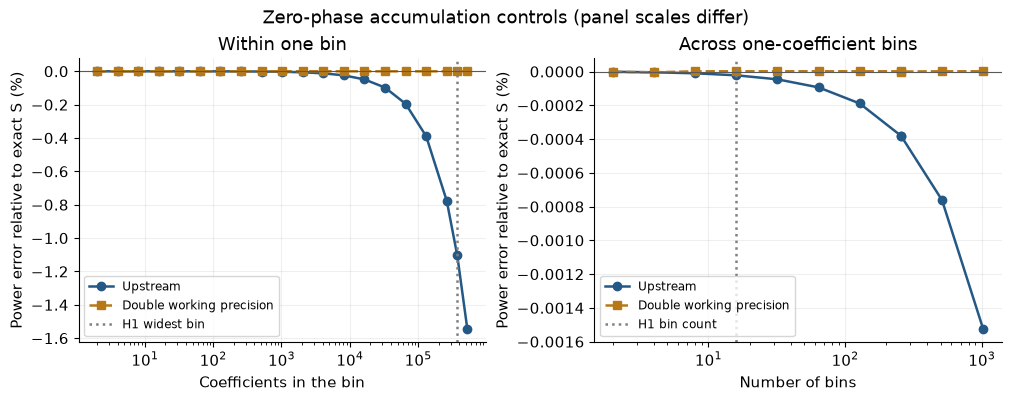

Within one bin, synthetic count 373,308, exact S = 1.0111563593
  Upstream: S = 1.0000000000
  Double working precision: S = 1.0111563206
Across one-coefficient bins, synthetic count 16, exact S = 1.0000002235
  Upstream: S = 1.0000000000
  Double working precision: S = 1.0000002384


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.9), constrained_layout=True)
cases = [
    (within_counts, within_exact, within, captured_width,
     "Within one bin", "Coefficients in the bin", "H1 widest bin"),
    (across_counts, across_exact, across, captured_bins,
     "Across one-coefficient bins", "Number of bins", "H1 bin count"),
]
for ax, (counts, exact, results, marker_x, title, xlabel, marker_label) in zip(axes, cases):
    for name, marker, style in zip(variants, ("o", "s"), ("-", "--")):
        error = 100 * (results[name] - exact) / exact
        ax.plot(counts, error, marker=marker, linestyle=style,
                color=colors[name], label=labels[name])
    ax.axhline(0, color="0.35", linewidth=0.8)
    ax.axvline(marker_x, color="0.5", linestyle=":", label=marker_label)
    ax.set(xscale="log", xlabel=xlabel, ylabel="Power error relative to exact S (%)",
           title=title)
    ax.legend(fontsize=8.5)
fig.suptitle("Zero-phase accumulation controls (panel scales differ)")
plt.show()
for counts, exact, results, marker_x, title, _, _ in cases:
    j = int(np.flatnonzero(counts == marker_x)[0])
    print(f"{title}, synthetic count {marker_x:,}, exact S = {exact[j]:.10f}")
    for name in variants:
        print(f"  {labels[name]}: S = {results[name][j]:.10f}")

## What this establishes

The arithmetic patch promotes phases, products, within-bin sums and the total power jointly, rounding the result to float32 once. These controls separate two accumulation mechanisms; they do not establish that every rounded operation is an independent bug.

The [saved H1 input](../data/point-input-05.json) has 16 bins and a widest bin of 373,308 coefficients; the dotted lines mark those sizes, not real-data errors. Its coefficients and phases differ. See [the real-data replay](arithmetic_real_data.ipynb) for the measured effect of using double working precision and [phase.ipynb](phase.ipynb) for the rotation control. Individual contributions to that replay cannot be inferred from these synthetic curves.